### Imports

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append('/teamspace/studios/this_studio/Human-Activity-Recognition')
from src.cnn import build_cnn
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os
import requests
import zipfile

### Download Data

In [18]:
def download_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    data_path = "data/UCI_HAR_Dataset.zip"

    if not os.path.exists('data'):
        os.makedirs('data')

    if not os.path.exists(data_path):
        response = requests.get(url)
        with open(data_path, 'wb') as f:
            f.write(response.content)

        with zipfile.ZipFile(data_path, 'r') as zip_ref:
            zip_ref.extractall('data')

download_data()

### Load & Preprocess Raw Sensor Data


In [7]:
sensor_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',     # Accelerometer measurements
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',  # Gyroscope measurements
    'total_acc_x', 'total_acc_y', 'total_acc_z'     # Raw accelerometer measurements before filtering (total acceleration)
]

def load_data(split_type):
    signals = []

    for sensor_name in sensor_names:
        file_path = os.path.join(f'../data/UCI HAR Dataset/{split_type}/Inertial Signals/{sensor_name}_{split_type}.txt')
        signal = pd.read_csv(file_path, delim_whitespace=True, header=None).values
        signals.append(signal)

    return np.stack(signals, axis=2)

def load_labels(split_type):
    file_path = os.path.join(f'../data/UCI HAR Dataset/{split_type}/y_{split_type}.txt')
    # Convert 1 - 6 to 0 - 5
    return pd.read_csv(file_path, delim_whitespace=True, header=None).values.flatten() - 1

def normalize_data(X_train_raw, X_test_raw):
    n_train_samples, n_train_timesteps, n_train_features = X_train_raw.shape
    n_test_samples, n_test_timesteps, n_test_features = X_test_raw.shape

    X_train_norm = np.zeros_like(X_train_raw)
    X_test_norm = np.zeros_like(X_test_raw)

    for i in range(n_train_features):
        scaler = StandardScaler()
        # Fit training data only and transform both
        X_train_norm[:, :, i] = scaler.fit_transform(X_train_raw[:, :, i])
        X_test_norm[:, :, i] = scaler.transform(X_test_raw[:, :, i])

    return X_train_norm, X_test_norm

X_train_raw = load_data('train')
X_test_raw = load_data('test')
y_train = load_labels('train')
y_test = load_labels('test')
X_train_norm, X_test_norm = normalize_data(X_train_raw, X_test_raw)


### Build & Train The CNN

In [8]:
model = build_cnn()
model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

history = model.fit(
    X_train_norm, y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10)
    ]
)

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778407055.432047    5026 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,038 (2.49 MB)

 Trainable params: 651,142 (2.48 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7133 - loss: 0.7258 - val_accuracy: 0.8171 - val_loss: 0.5298
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8936 - loss: 0.2815 - val_accuracy: 0.9021 - val_loss: 0.3402
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9335 - loss: 0.1623 - val_accuracy: 0.8851 - val_loss: 0.3988
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9425 - loss: 0.1467 - val_accuracy: 0.9123 - val_loss: 0.3759
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9398 - loss: 0.1451 - val_accuracy: 0.9123 - val_loss: 0.4008
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9471 - loss: 0.1155 - val_accuracy: 0.9028 - val_loss: 0.4438
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9485 - loss: 0.1108 - val_accuracy: 0.9218 - val_loss: 0.4376
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9502 - loss: 0.1303 - val_accuracy: 0.9232 - v

### Plots

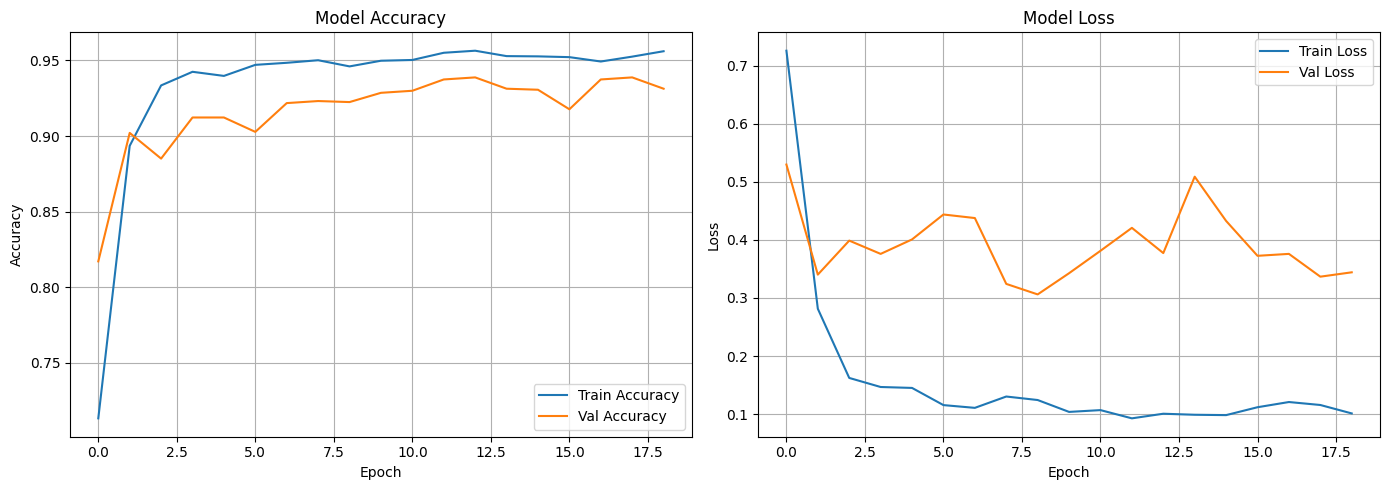

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()